[*********************100%***********************]  3 of 3 completed



--- Data successfully loaded into a Vector Space ---
Vector dimensions: (365, 3) (Days x Assets)
Ticker            AAPL       BTC-USD       GOLD
Date                                           
2024-01-02  183.731323  44957.968750  27.755007
2024-01-03  182.355606  42848.175781  26.896797
2024-01-04  180.039658  44179.921875  27.604115
2024-01-05  179.317154  44162.691406  27.490936
2024-01-06  179.317154  43989.195312  27.490936


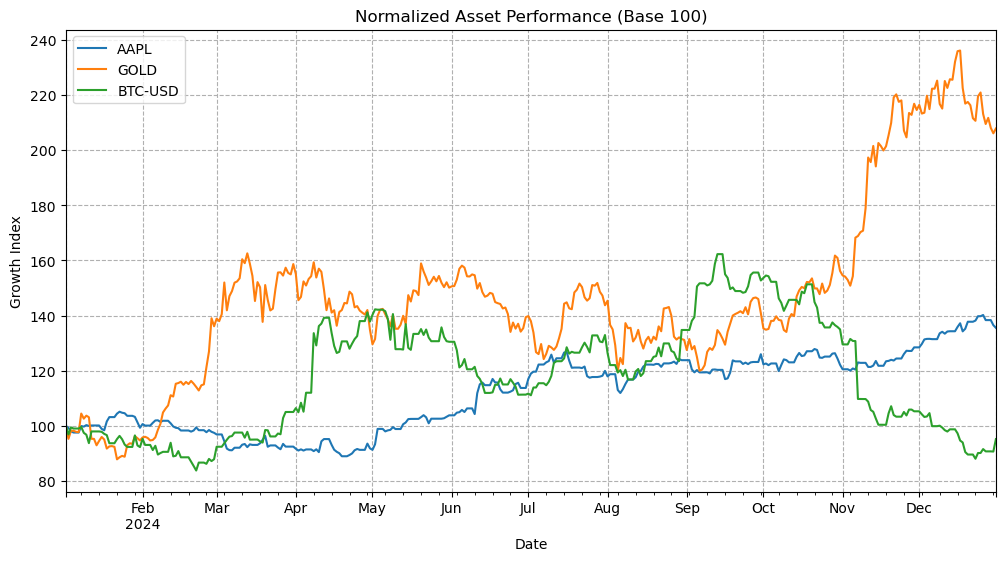

In [22]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


assets = ['AAPL', 'GOLD', 'BTC-USD'] 

def download_data(tickers, start_date="2024-01-01", end_date="2025-01-01"):
    """
    Fetches historical price data. 
    Using auto_adjust=True to ensure 'Close' represents the Adjusted price.
    Reference: yfinance documentation (https://pypi.org)
    """
    print(f"Downloading data for: {tickers}...")
    # auto_adjust=True handles the 'Adj Close' vs 'Close' issue automatically
    data = yf.download(tickers, start=start_date, end=end_date, auto_adjust=True)
    
    # Extract only the 'Close' column group
    return data['Close']


df = download_data(assets)


if df.empty:
    print("Error: No data downloaded. Check your internet connection or tickers.")
else:
    df = df.ffill().dropna() 
    print("\n--- Data successfully loaded into a Vector Space ---")
    print(f"Vector dimensions: {df.shape} (Days x Assets)")
    print(df.head())

    # Since BTC is $60k and GOLD is $2k, we normalize to start at 100 
    # to compare their "Rate of Change" (Calculus prep)
    df_normalized = (df / df.iloc[0]) * 100  
    df_normalized.plot(figsize=(12, 6))
    plt.title("Normalized Asset Performance (Base 100)")
    plt.xlabel("Date")
    plt.ylabel("Growth Index")
    plt.legend(assets)
    plt.grid(True, linestyle='--')
    plt.show()

Weight Vector (w): [0.4 0.2 0.4]
Sum of weights: 1.0 (Verification of Unity)


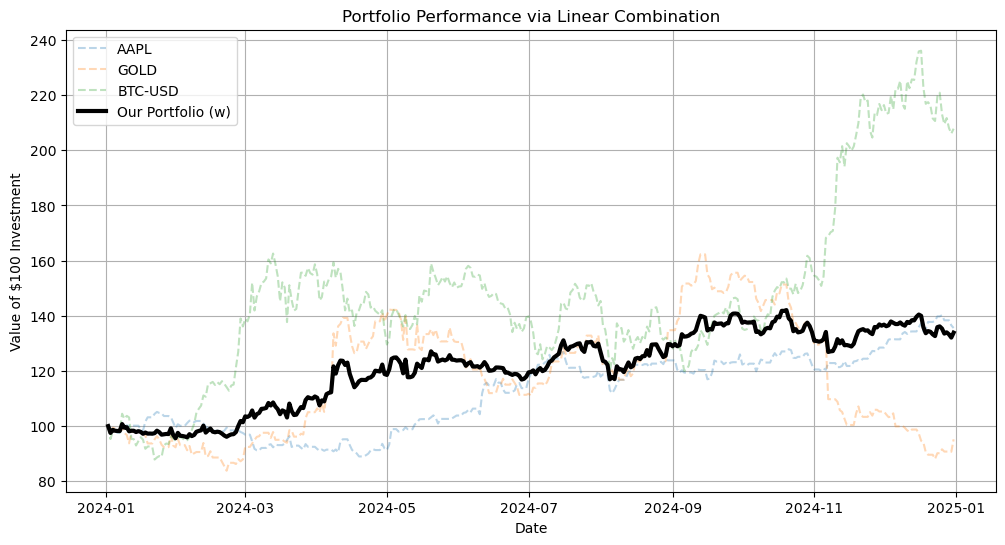


Final Portfolio Value: 133.87


In [23]:
#  Define our Weight Vector (Must sum to 1.0)
# Example: 40% Apple, 20% Gold, 40% Bitcoin
weights = np.array([0.4, 0.2, 0.4])

print(f"Weight Vector (w): {weights}")
print(f"Sum of weights: {np.sum(weights)} (Verification of Unity)")

# Portfolio Calculation using the Dot Product (Linear Algebra)
# We use the normalized data from Day 1 to see growth from a $100 investment
# Formula: Portfolio_Value = Data_Matrix · Weight_Vector
portfolio_value = df_normalized.dot(weights)

# Add the portfolio to our DataFrame for comparison
df_normalized['PORTFOLIO'] = portfolio_value

# Visualization of the Weighted Vector
plt.figure(figsize=(12, 6))
for asset in assets:
    plt.plot(df_normalized[asset], label=asset, alpha=0.3, linestyle='--')

plt.plot(df_normalized['PORTFOLIO'], color='black', linewidth=3, label='Our Portfolio (w)')

plt.title("Portfolio Performance via Linear Combination")
plt.xlabel("Date")
plt.ylabel("Value of $100 Investment")
plt.legend()
plt.grid(True)
plt.show()

print("\nFinal Portfolio Value:", round(df_normalized['PORTFOLIO'].iloc[-1], 2))

--- Statistical Moments of Asset Vectors ---
         Mean (Return)  Volatility (StdDev)  Skewness   Kurtosis
Ticker                                                          
AAPL          0.000904             0.011736  0.708124   6.787698
BTC-USD       0.002399             0.028006  0.500723   2.000609
GOLD          0.000170             0.024810  0.797691  15.251049


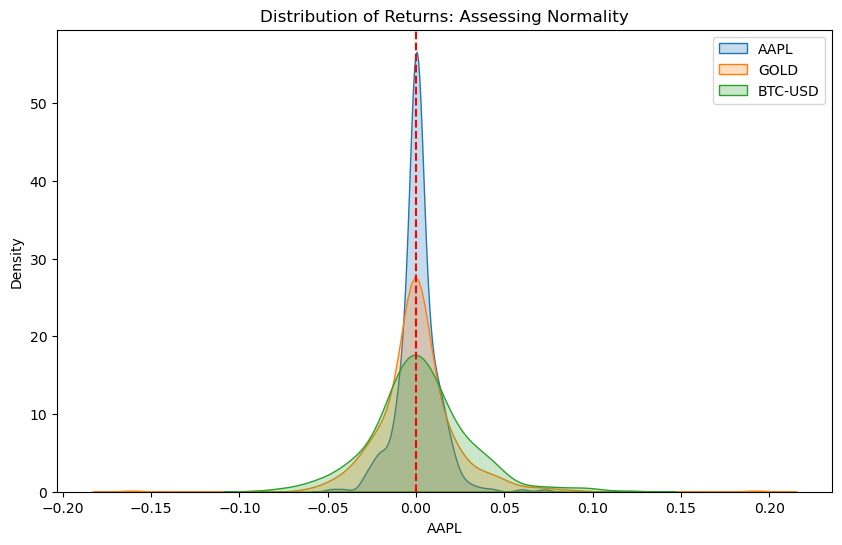

In [24]:

# Calculate the daily percentage change (the 'velocity' of price)
returns = df.pct_change().dropna()
# Higher Statistical Moments 
stats_summary = pd.DataFrame({
    'Mean (Return)': returns.mean(),
    'Volatility (StdDev)': returns.std(),
    'Skewness': returns.skew(),    # 3rd Moment: Symmetry of risk
    'Kurtosis': returns.kurtosis() # 4th Moment: Likelihood of extreme crashes
})

print("--- Statistical Moments of Asset Vectors ---")
print(stats_summary)

# Visualization of the Distribution
import seaborn as sns
plt.figure(figsize=(10, 6))
for asset in assets:
    sns.kdeplot(returns[asset], label=asset, fill=True)

plt.title("Distribution of Returns: Assessing Normality")
plt.axvline(0, color='red', linestyle='--')
plt.legend()
plt.show()

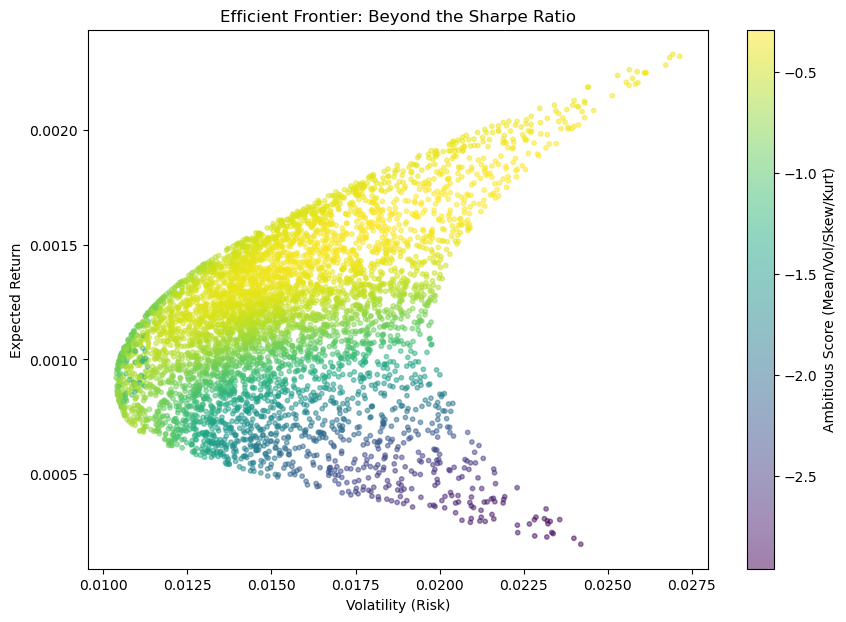

 OPTIMAL WEIGHT VECTOR 
AAPL      : 0.44%
GOLD      : 72.86%
BTC-USD   : 26.71%
------------------------------
Total Sum: 1.0
Best Portfolio Score: -0.288345
Standard Sharpe at this point: 0.080630


In [25]:
# -- Monte Carlo Simulation --
num_portfolios = 5000
results = np.zeros((7, num_portfolios)) # Row for: Mean, Vol, Skew, Kurt, Sharpe, Score, and Weights pointer

# Create an empty list or array to store the actual weights for each run
all_weights = np.zeros((num_portfolios, len(assets)))

# Risk Aversion Coefficients (Can adjust these to change the 'Math Strategy')
lambda_var = 0.5   # Penalty for Volatility
lambda_skew = 0.1  # Reward for Positive Skewness (Right-leaning returns)
lambda_kurt = 0.2  # Penalty for Kurtosis (Extreme tail risk)

# Convert returns to a numpy array for speed
returns_arr = returns.values

for i in range(num_portfolios):
    # 1. Generate Random Weight Vector (Linear Algebra)
    w = np.random.random(len(assets))
    w /= np.sum(w) # Normalize so sum = 1.0
    all_weights[i,:] = w
    
    # 2. Calculate Portfolio Returns Vector
    p_returns = np.dot(returns_arr, w)    
    
    # 3. Calculate 4 Statistical Moments (Advanced Features)
    p_mean = np.mean(p_returns)
    p_std = np.std(p_returns)
    p_skew = pd.Series(p_returns).skew()
    p_kurt = pd.Series(p_returns).kurtosis()
    
    # 4. Standard Sharpe Ratio (The 'Simple' Metric)
    sharpe = p_mean / p_std if p_std != 0 else 0
    
    # 5. Ambitious 'Score' (Including Higher Moments)
    #  add Skewness and subtract Kurtosis
    score = p_mean - (lambda_var * p_std) + (lambda_skew * p_skew) - (lambda_kurt * p_kurt)
    
    # Store results
    results[0,i] = p_mean
    results[1,i] = p_std
    results[2,i] = p_skew
    results[3,i] = p_kurt
    results[4,i] = sharpe
    results[5,i] = score
  

# --- Visualization: The Modern Efficient Frontier ---
plt.figure(figsize=(10, 7))

# Color the dots 
plt.scatter(results[1,:], results[0,:], c=results[5,:], cmap='viridis', marker='o', s=10, alpha=0.5)
plt.colorbar(label='Score (Mean/Vol/Skew/Kurt)')
plt.xlabel('Volatility (Risk)')
plt.ylabel('Expected Return')
plt.title('Efficient Frontier')
plt.show()

# Find the best portfolio by our Score
best_idx = np.argmax(results[5,:])
best_weights = all_weights[best_idx,:]

print("="*30)
print(" OPTIMAL WEIGHT VECTOR ")
print("="*30)
for asset, weight in zip(assets, best_weights):
    print(f"{asset:10}: {weight*100:.2f}%")

print("-" * 30)
print(f"Total Sum: {np.sum(best_weights):.1f}")
print(f"Best Portfolio Score: {results[5,best_idx]:.6f}")
print(f"Standard Sharpe at this point: {results[4,best_idx]:.6f}")
